# Bank Customer Churn Prediction

## 1. Problem Statement

A retail bank wants to reduce customer attrition by identifying which customers are likely to close their accounts, so the retention team can target them with offers before they leave.

- **ML task:** Binary classification
- **Target:** `Exited` (1 = customer churned, 0 = customer retained)
- **observation unit:** One row per bank customer (single snapshot, no timestamp)
- **Candidate features:** CeditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary
- **Excluded:** RowNumber, CustomerId, Surname -- identifiers with no predictive meaning, dropped to avoid the model latching onto row order or arbitrary IDs
- **Evaluation metrics:** Recall, precision, F1, ROC-AUC -- not accuracy alone. The target is imbalanced (~80/20), so a model predicting "stays" for every customer would score 80% accuracy while being completely useless for the business goal.
- **Business metric:** Retained revenue from customers correctly flagged and re-engaged by the retention team

In [1]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
from pprint import pprint

business_to_ml_blueprint = {
    'business_goal': 'predict which customers may close their accounts and target them with retention offers',
    'ml_task': 'binary_classification',
    'target': 'Exited',
    'observation_unit': 'one-row-per-bank-customer snapshot',
    'candidate_features': [
        'CreditScore',
        'Geography',
        'Gender',
        'Age',
        'Tenure',
        'Balance',
        'NumOfProducts',
        'HasCrCard',
        'IsActiveMember',
        'EstimatedSalary'
    ],
    'excluded_features': [
        'RowNumber',
        'CustomerId',
        'Surname'
    ],
    'model_metrics': ['recall', 'precision', 'f1', 'pr_auc'],
    'business_metric': 'retained_revenue_from_correctly_flagged_customers',
    'guardrail': 'exclude identifier columns, no post-outcome features present in this dataset'
}

pprint(business_to_ml_blueprint)

{'business_goal': 'predict which customers may close their accounts and target '
                  'them with retention offers',
 'business_metric': 'retained_revenue_from_correctly_flagged_customers',
 'candidate_features': ['CreditScore',
                        'Geography',
                        'Gender',
                        'Age',
                        'Tenure',
                        'Balance',
                        'NumOfProducts',
                        'HasCrCard',
                        'IsActiveMember',
                        'EstimatedSalary'],
 'excluded_features': ['RowNumber', 'CustomerId', 'Surname'],
 'guardrail': 'exclude identifier columns, no post-outcome features present in '
              'this dataset',
 'ml_task': 'binary_classification',
 'model_metrics': ['recall', 'precision', 'f1', 'pr_auc'],
 'observation_unit': 'one-row-per-bank-customer snapshot',
 'target': 'Exited'}


The dictionary above formalizes the problem statement into a structure the rest of the notebook builds from: it defines exactly which columns are legitimate inputs, which are excluded and why, and which metrics will be used to judge success later.

In [3]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATASET_ADDRESS = 'https://raw.githubusercontent.com/hamzanasirr/Exploratory-Data-Analysis-on-Bank-Customer-Churn-data/master/Churn_Modelling.csv'
df = pd.read_csv(DATASET_ADDRESS)

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Data Collection

**Dataset:** Bank Customer Churn ("Churn Modeling"), 10_000 rows, 14 columns, originally distributed via Kaggle, loaded from a stable Github mirror so the notebook runs without a manual download step.

Source: https://kaggle.com/datasets/mathchi/churn-for-bank-customers

In [4]:
print("Data types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nFully duplicated rows:", df.duplicated().sum())
print("Duplicate CustomerId values:", df["CustomerId"].duplicated().sum())

Data types:
 RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values per column:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Fully duplicated rows: 0
Duplicate CustomerId values: 0


10_000 rows and 14 columns confirms a dataset well above trivial size, with a mix of numeric (CreditScore, Age, Balance ...) and categorical (Geography, Gender) features -- a realistic feature-type mix for a business classification problem.

In [5]:
print("Target distribution (counts):")
print(df["Exited"].value_counts())
print("\nTarget distribution (proportion):")
print(df["Exited"].value_counts(normalize=True).round(4))

Target distribution (counts):
Exited
0    7963
1    2037
Name: count, dtype: int64

Target distribution (proportion):
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


No missing values in any column and no duplicate rows or CustomerIds -- unusually clean for a real-world dataset, so no imputation strategy is needed here. This is stated plainly rather than invented, since not every dataset needs a missing data story

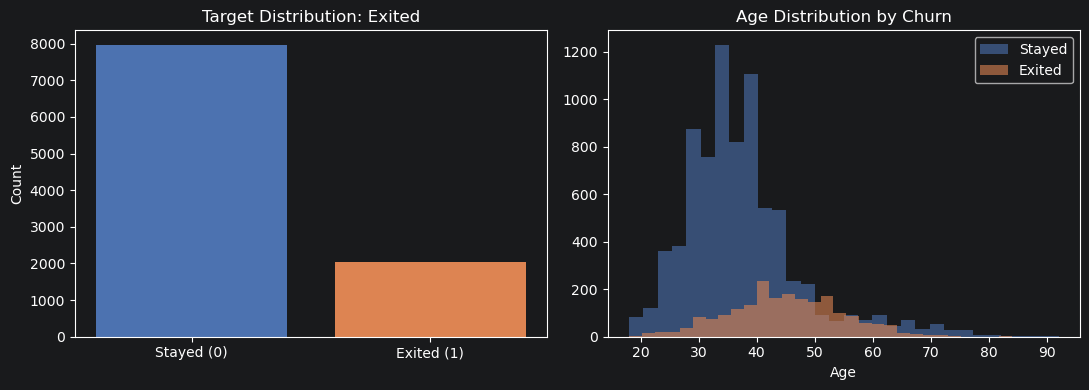

In [6]:
# Target distribution + Age split

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df["Exited"].value_counts().sort_index()
axes[0].bar(["Stayed (0)", "Exited (1)"], counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Target Distribution: Exited")
axes[0].set_ylabel("Count")

axes[1].hist(df[df["Exited"]==0]["Age"], bins=30, alpha=0.6, label="Stayed", color="#4C72B0")
axes[1].hist(df[df["Exited"]==1]["Age"], bins=30, alpha=0.6, label="Exited", color="#DD8452")
axes[1].set_title("Age Distribution by Churn")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.show()

The target is imbalanced: 7,963 customers stayed (79.6%) vs 2,037 who churned (20.4%). This confirms the concern raised in the problem statement; a model that ignores the minority class can still score highly on accuracy while being useless for retention targeting. This is the reason recall, F1, and ROC-AUC are used throughout instead of accuracy alone.

## 3. Exploratory Data Analysis

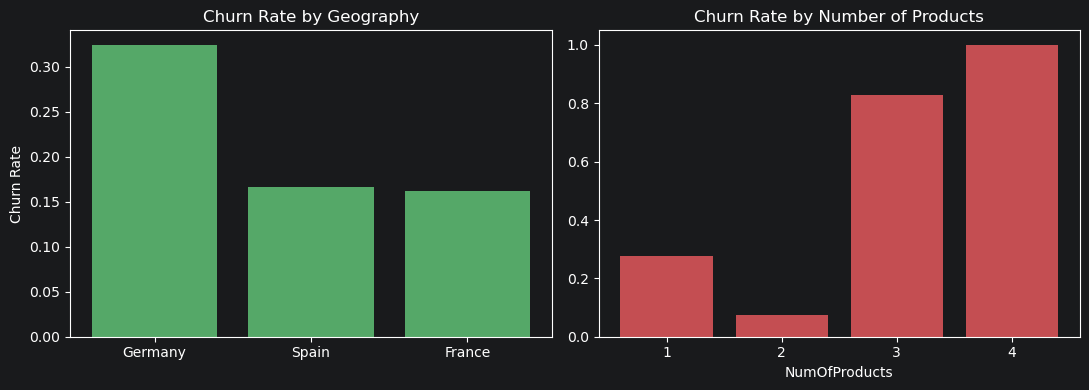

In [7]:
# Churn rate by category

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

geo_churn = df.groupby("Geography")["Exited"].mean().sort_values(ascending=False)
axes[0].bar(geo_churn.index, geo_churn.values, color="#55A868")
axes[0].set_title("Churn Rate by Geography")
axes[0].set_ylabel("Churn Rate")

prod_churn = df.groupby("NumOfProducts")["Exited"].mean()
axes[1].bar(prod_churn.index.astype(str), prod_churn.values, color="#C44E52")
axes[1].set_title("Churn Rate by Number of Products")
axes[1].set_xlabel("NumOfProducts")

plt.tight_layout()
plt.show()

Two clear patterns emerge:

- **Geography:** Germany churns at 32.4%, roughly double France (16.2%) and Spain (16.7%).
- **NumOfProducts** shows the most striking pattern in the whole dataset and it is *not* a smooth trend:

| NumOfProducts | Customers | Churn rate |
|---|---|---|
| 1 | 5,084 | 27.7% |
| 2 | 4,590 | 7.6% |
| 3 | 266 | 82.7% |
| 4 | 60 | 100.0% |

Customers with 2 products are the *most* loyal, while 3+ products almost guarantees churn. This is counterintuitive; more products might be expected to mean more lock-in; and could reflect aggressive cross-selling leading to dissatisfaction, through the very small group sizes at 3-4 products (266 and 60 customers) mean this pattern should be treated with some caution rather than taken as fully reliable.

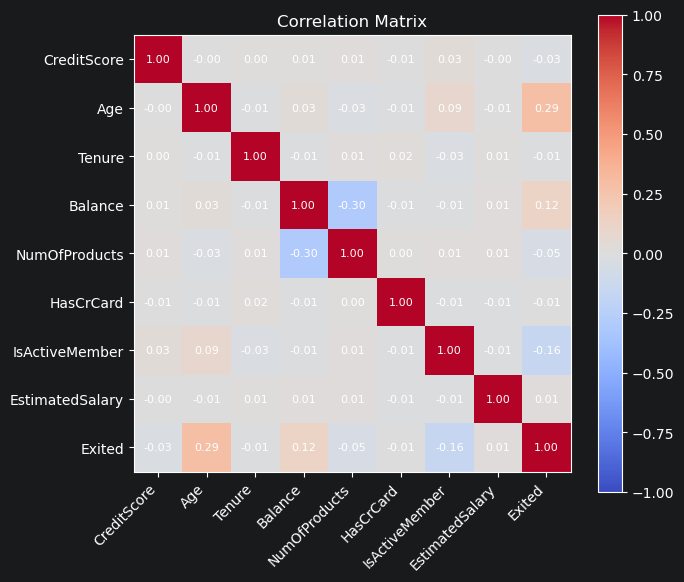

In [8]:
# Correlation with target (numeric features only)

numeric_cols = ["CreditScore","Age","Tenure","Balance","NumOfProducts",
                 "HasCrCard","IsActiveMember","EstimatedSalary","Exited"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Linear correlation with `Exited` ranks Age (0.29) and IsActiveMember (-0.16) as the strongest predictors, but NumOfProducts shows almost no linear correlation (-0.05); despite being the single strongest signal found in the bar chart above. This is because Pearson correlation only captures linear relationships, and the NumOfProducts-churn relationship is sharply non-linear. Relying on correlation alone would have caused this feature`s importance to be missed entirely

## 4. cleaning & feature engineering

RowNumber, CustomerId, and Surname are dropped. they are identifiers with no generalizable relationship to why a customer leaves, and keeping CustomerId in particular risks a model overfitting to memorized IDs rather than learning real patterns.

In [9]:
# cleaning and feture engineering

df_clean = df.drop(columns=business_to_ml_blueprint.get("excluded_features"))
print(df_clean.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [10]:
df_clean["HasZeroBalance"] = (df_clean["Balance"] == 0).astype(int)

36.2% of customers have exactly €0 balance. Checking the churn rate within that group shows something non-obvious: customers with zero balance churn *less* (13.8%) than customers with money in the account (24.1%). the opposite of an intuitive "empty account = disengaged" assumption. Because this is a real, informative pattern rather than a data-quality issue, it is kept as an explicit binary feature (`HasZeroBalance`) rather than left buried inside the raw `Balance` value, or treated as missing data.

In [11]:
print(df_clean.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'HasZeroBalance']


In [12]:
numeric_features = ["CreditScore", "Age", "Tenure", "Balance",
                     "NumOfProducts", "EstimatedSalary", "HasZeroBalance", "HasCrCard", "IsActiveMember"]
categorical_features = ["Geography", "Gender"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

`Geography` and `Gender` are one-hot encoded rather than ordinal-encoded, since they have no natural order. encoding them as 0/1/2 would falsely imply a ranking (e.g. Germany > Spain > France) that doesn't exist and could mislead distance-based or linear models. `drop="first"` avoids redundant columns, and `handle_unknown="ignore"` protects against unseen categories at prediction time.

## 5. Train/Test Split

An 80/20 split is used, stratified on `Exited`. With ~2,000 test rows at a ~20% churn rate, this leaves roughly 400 churned customers in the test set enough for a reasonably stable estimate of precision/recall on the minority class, without sacrificing too much training data given the dataset's overall size. `stratify=y` ensures both train and test preserv the same ~20% churn rate.

In [13]:
X = df_clean.drop(columns=["Exited"])
y = df_clean["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 3), "| Test churn rate:", round(y_test.mean(), 3))

Train shape: (8000, 11) Test shape: (2000, 11)
Train churn rate: 0.204 | Test churn rate: 0.204


## 6. Data Engineering Comparison

In [14]:
preprocessor_scaled = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

preprocessor_unscaled = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

In [15]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}
strategies = {
    "scaled": preprocessor_scaled,
    "unscaled": preprocessor_unscaled,
}

results = []
for model_name, model in models.items():
    for strat_name, prep in strategies.items():
        pipe = Pipeline([("prep", prep), ("clf", model)])
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
        results.append({"model": model_name, "preprocessing": strat_name,
                         "mean_roc_auc": scores.mean(), "std": scores.std()})

results_df = pd.DataFrame(results).sort_values("mean_roc_auc", ascending=False)
results_df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

,model,preprocessing,mean_roc_auc,std
2,KNN (k=5),scaled,0.779257,0.018522
0,LogisticRegression,scaled,0.762515,0.020536
1,LogisticRegression,unscaled,0.754117,0.020271
3,KNN (k=5),unscaled,0.525020,0.011919


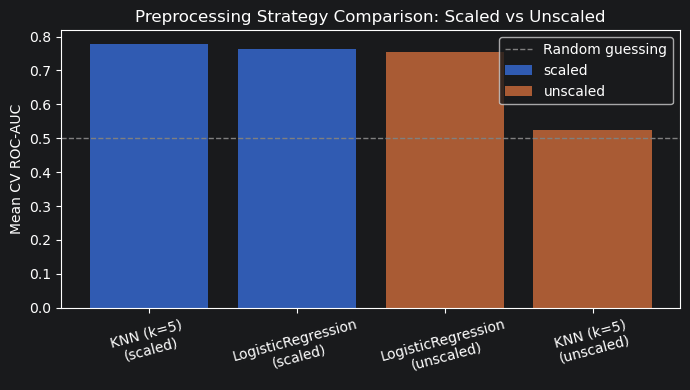

In [16]:
fig, ax = plt.subplots(figsize=(7,4))
for strat in ["scaled", "unscaled"]:
    subset = results_df[results_df["preprocessing"] == strat]
    ax.bar([f"{m}\n({strat})" for m in subset["model"]], subset["mean_roc_auc"],
           label=strat, alpha=0.8)
ax.set_ylabel("Mean CV ROC-AUC")
ax.set_title("Preprocessing Strategy Comparison: Scaled vs Unscaled")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random guessing")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
}

scoring = ["roc_auc", "f1", "precision", "recall"]
cv_results_summary = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor_scaled), ("clf", model)])
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    row = {"model": name}
    for metric in scoring:
        row[metric] = cv_results[f"test_{metric}"].mean()
    cv_results_summary.append(row)

cv_results_df = pd.DataFrame(cv_results_summary)
cv_results_df

,model,roc_auc,f1,precision,recall
0,LogisticRegression,0.762515,0.312847,0.597070,0.212270
1,RandomForest,0.852619,0.566198,0.759654,0.451534


In [18]:
fitted_pipes = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor_scaled), ("clf", model)])
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe
print("Fitted:", list(fitted_pipes.keys()))

Fitted: ['LogisticRegression', 'RandomForest']


## 8. Hyperparameter tuning

In [19]:
from sklearn.model_selection import GridSearchCV

pipe_lr = Pipeline([("prep", preprocessor_scaled),
                     ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])

param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"],
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring="f1", cv=cv, n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best params:", grid_lr.best_params_)
print("Best CV F1:", round(grid_lr.best_score_, 4))

Best params: {'clf__C': 10, 'clf__class_weight': 'balanced'}
Best CV F1: 0.4879


In [20]:
pipe_rf = Pipeline([("prep", preprocessor_scaled),
                     ("clf", RandomForestClassifier(random_state=RANDOM_STATE))])

param_grid_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10],
    "clf__min_samples_leaf": [1, 5],
    "clf__class_weight": [None, "balanced"],
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring="f1", cv=cv, n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
print("Best CV F1:", round(grid_rf.best_score_, 4))

Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
Best CV F1: 0.619


## 9. Final Evaluation

In [21]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

final_models = {
    "LogisticRegression (tuned)": best_lr,
    "RandomForest (tuned)": best_rf,
}

for name, model in final_models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} ===")
    print("Test ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
    print("Test F1:", round(f1_score(y_test, pred), 4))
    print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
    print("\n", classification_report(y_test, pred, target_names=["Stayed", "Exited"]))


=== LogisticRegression (tuned) ===
Test ROC-AUC: 0.7769
Test F1: 0.5017

Confusion matrix:
 [[1143  450]
 [ 120  287]]

               precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1593
      Exited       0.39      0.71      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000


=== RandomForest (tuned) ===
Test ROC-AUC: 0.8647
Test F1: 0.6225

Confusion matrix:
 [[1387  206]
 [ 130  277]]

               precision    recall  f1-score   support

      Stayed       0.91      0.87      0.89      1593
      Exited       0.57      0.68      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.84      0.83      0.84      2000



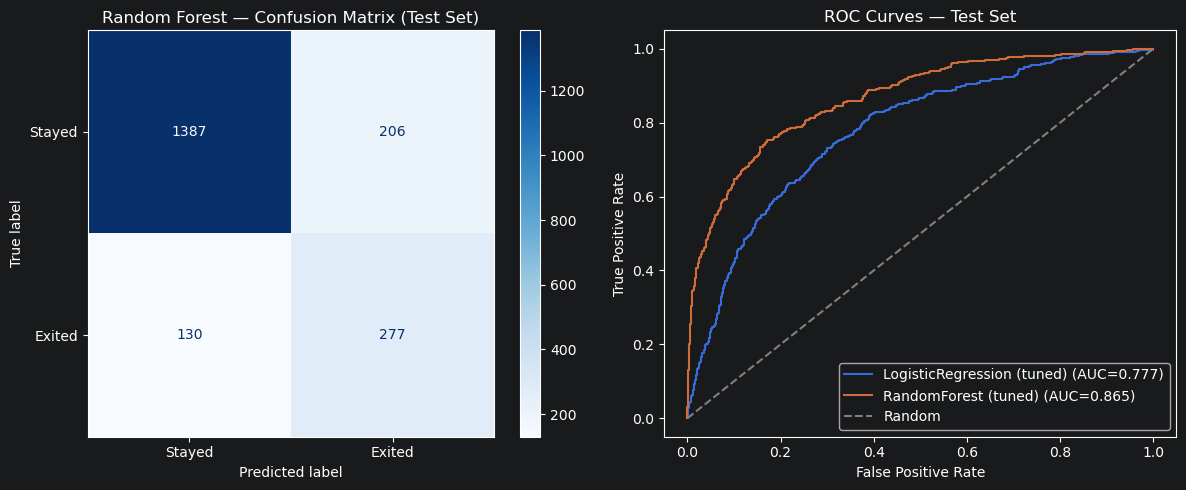

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test,
                                       display_labels=["Stayed","Exited"],
                                       ax=axes[0], cmap="Blues")
axes[0].set_title("Random Forest — Confusion Matrix (Test Set)")

for name, model in final_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")
axes[1].plot([0,1],[0,1], linestyle="--", color="gray", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — Test Set")
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
final_model = best_rf
print("Final selected model: Random Forest")
print("Best hyperparameters:", grid_rf.best_params_)
print("Test ROC-AUC:", round(roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]), 4))

Final selected model: Random Forest
Best hyperparameters: {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
Test ROC-AUC: 0.8647


## 10. Feature Importance & Discssion

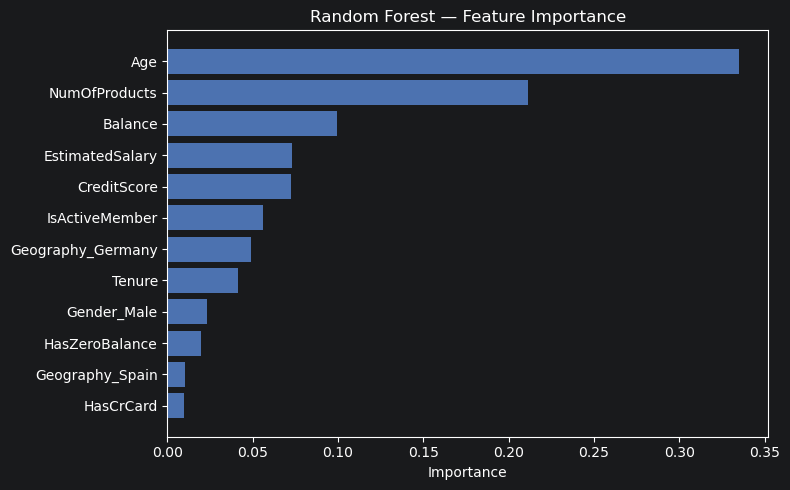

,feature,importance
1,Age,0.335134
4,NumOfProducts,0.211550
3,Balance,0.099524
5,EstimatedSalary,0.072910
0,CreditScore,0.072184
8,IsActiveMember,0.055815
9,Geography_Germany,0.049134
2,Tenure,0.041233
11,Gender_Male,0.023386
6,HasZeroBalance,0.019411


In [24]:
feature_names = (numeric_features +
                  list(final_model.named_steps["prep"]
                       .named_transformers_["cat"]
                       .get_feature_names_out(categorical_features)))

importances = final_model.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
           .sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#4C72B0")
ax.set_xlabel("Importance")
ax.set_title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

imp_df

## References

Hunter, J.D. (2007) 'Matplotlib: A 2D graphics environment', *Computing in Science & Engineering*, 9(3), pp. 90–95. Available at: https://matplotlib.org (Accessed: 13 August 2026).

Mathchi (2020) *Churn for Bank Customers* [Dataset]. Kaggle. Available at: https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers (Accessed: 13 August 2026).

McKinney, W. (2010) 'Data structures for statistical computing in Python', in *Proceedings of the 9th Python in Science Conference*, pp. 56–61. Available at: https://pandas.pydata.org (Accessed: 13 August 2026).

Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830. Available at: https://scikit-learn.org (Accessed: 13 August 2026).

scikit-learn developers (n.d.) *Preprocessing data*. Available at: https://scikit-learn.org/stable/modules/preprocessing.html (Accessed: 13 August 2026).

scikit-learn developers (n.d.) *GridSearchCV*. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html (Accessed: 13 August 2026).

scikit-learn developers (n.d.) *Ensemble methods: Random forests*. Available at: https://scikit-learn.org/stable/modules/ensemble.html#random-forests (Accessed: 13 August 2026).